# 0. Importação dos dados



In [22]:
# importação das bibliotecas

from collections import Counter

import folium

from folium.plugins import HeatMap

import pandas as pd

import matplotlib.pyplot as plt

In [23]:
url_1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url_2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url_3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url_4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja_1 = pd.read_csv(url_1)
loja_2 = pd.read_csv(url_2)
loja_3 = pd.read_csv(url_3)
loja_4 = pd.read_csv(url_4)

lojas = [loja_1, loja_2, loja_3, loja_4]

### Estrutura dos Dados: O dataset inclui as seguintes informações:

- Produto e Categoria: Itens vendidos e suas classificações.

- Preço e Frete: Valores das vendas e custos associados.

- Data de Compra e Local: Informações temporais e geográficas.

- Avaliação da Compra: Feedback dos clientes.

- Tipo de Pagamento e Parcelas: Métodos utilizados pelos clientes.

- Coordenadas Geográficas: Localização das transações.

In [24]:
for loja in lojas:

    print(loja.head())
    print(loja.shape)

                 Produto Categoria do Produto    Preço      Frete  \
0     Assistente virtual          eletronicos   219.08   9.249790   
1         Mesa de jantar               moveis   256.35  11.234305   
2      Jogo de tabuleiro           brinquedos   279.51  21.262681   
3            Micro-ondas     eletrodomesticos  1009.99  54.667344   
4  Cadeira de escritório               moveis   446.99  26.964689   

  Data da Compra        Vendedor Local da compra  Avaliação da compra  \
0     16/01/2021     Pedro Gomes              SP                    4   
1     18/05/2022  Beatriz Moraes              RJ                    1   
2     15/03/2021      João Souza              DF                    1   
3     03/05/2022      João Souza              RS                    4   
4     07/11/2020   Larissa Alves              MG                    5   

  Tipo de pagamento  Quantidade de parcelas    lat    lon  
0    cartao_credito                       8 -22.19 -48.79  
1    cartao_credito       

# 1. Análise do faturamento

Nesta primeira análise, você deve calcular o **faturamento total** de cada loja. Somando os valores da coluna **Preço** de cada loja para estimar o faturamento.

In [25]:
#Faturamento bruto lojas:

lista_faturamentos_brutos = []

for i, loja in enumerate(lojas, start=1):
    faturamento = round(loja['Preço'].sum(), 2)
    lista_faturamentos_brutos.append(faturamento)
    print(f"Faturamento bruto loja {i}: R$ {faturamento}")


Faturamento bruto loja 1: R$ 1534509.12
Faturamento bruto loja 2: R$ 1488459.06
Faturamento bruto loja 3: R$ 1464025.03
Faturamento bruto loja 4: R$ 1384497.58


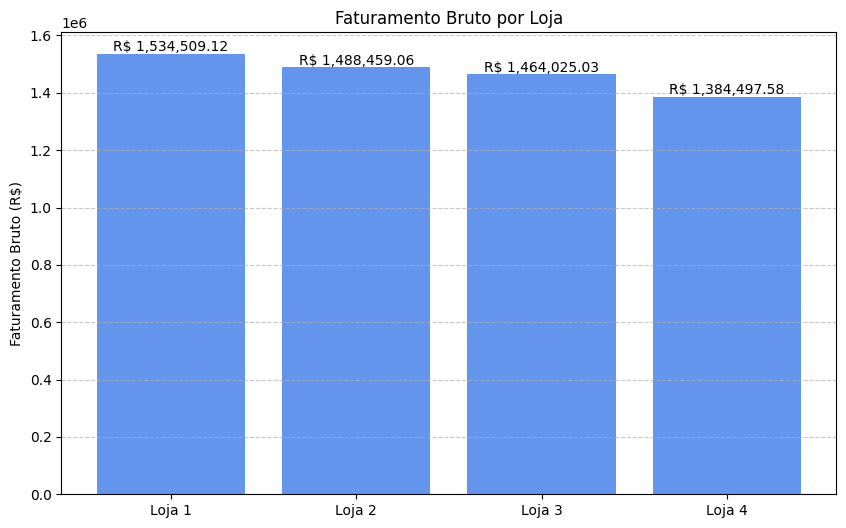

In [26]:
nomes_lojas = [f"Loja {i}" for i in range(1, len(lista_faturamentos_brutos) + 1)]

# Criar o gráfico
plt.figure(figsize=(10, 6))
barras = plt.bar(nomes_lojas, lista_faturamentos_brutos, color='cornflowerblue')

plt.ylabel('Faturamento Bruto (R$)')
plt.title('Faturamento Bruto por Loja')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona os valores em cima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.5,
             f'R$ {altura:,.2f}', ha='center', va='bottom')

plt.show()

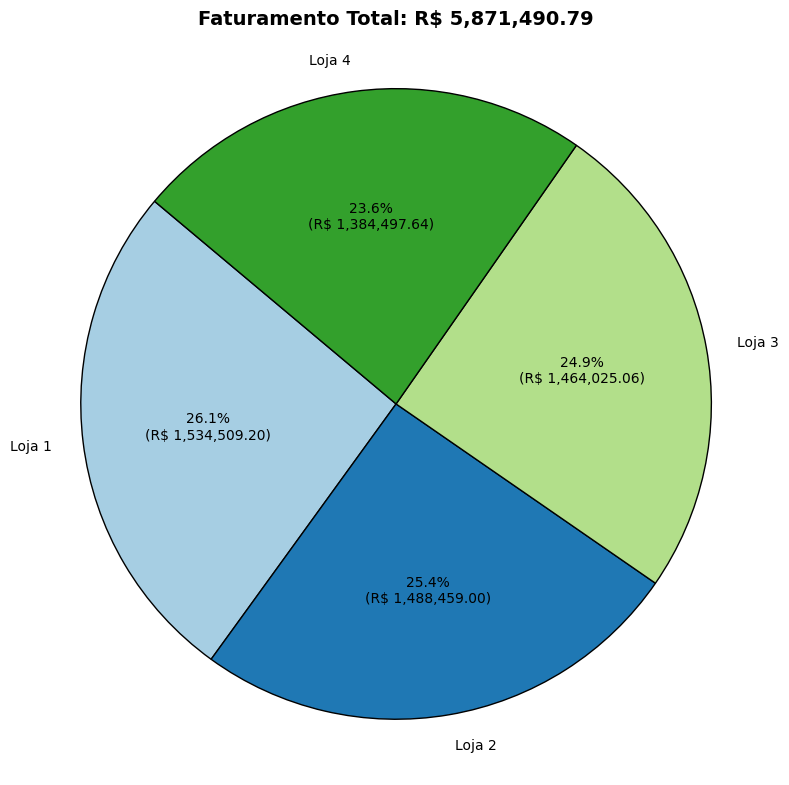

In [27]:
# Nomes das lojas
nomes_lojas = [f"Loja {i}" for i in range(1, len(lista_faturamentos_brutos) + 1)]

# Faturamento total
faturamento_total = sum(lista_faturamentos_brutos)

# Criar gráfico de pizza
plt.figure(figsize=(8, 8))
cores = plt.cm.Paired(range(len(nomes_lojas)))  # Cores automáticas

plt.pie(
    lista_faturamentos_brutos,
    labels=nomes_lojas,
    autopct=lambda p: f'{p:.1f}%\n(R$ {p * faturamento_total / 100:,.2f})',
    colors=cores,
    startangle=140,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'black'}
)

# Título com o faturamento total
plt.title(f'Faturamento Total: R$ {faturamento_total:,.2f}', fontsize=14, weight='bold')

plt.axis('equal')  # Deixar o círculo certinho
plt.tight_layout()
plt.show()


# 2. Vendas por Categoria
Neste passo, deve calcular a **quantidade de produtos vendidos** por **categoria** em cada loja. A ideia é agrupar os dados por categoria e contar o número de vendas de cada tipo, mostrando **as categoria mais populares** de cada loja


In [28]:
venda_por_categoria = []

for i, loja in enumerate(lojas, start=1):
    venda_categoria = loja['Categoria do Produto'].value_counts()
    venda_por_categoria.append(venda_categoria)
    print(f"Vendas por categoria da loja {i}:\n{venda_categoria}\n")

Vendas por categoria da loja 1:
Categoria do Produto
moveis                   465
eletronicos              448
brinquedos               324
eletrodomesticos         312
esporte e lazer          284
instrumentos musicais    182
livros                   173
utilidades domesticas    171
Name: count, dtype: int64

Vendas por categoria da loja 2:
Categoria do Produto
moveis                   442
eletronicos              422
brinquedos               313
eletrodomesticos         305
esporte e lazer          275
instrumentos musicais    224
livros                   197
utilidades domesticas    181
Name: count, dtype: int64

Vendas por categoria da loja 3:
Categoria do Produto
moveis                   499
eletronicos              451
brinquedos               315
eletrodomesticos         278
esporte e lazer          277
livros                   185
instrumentos musicais    177
utilidades domesticas    177
Name: count, dtype: int64

Vendas por categoria da loja 4:
Categoria do Produto
moveis     

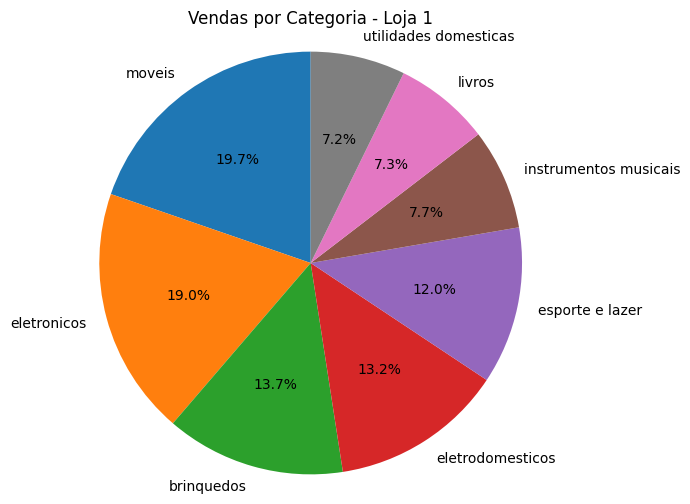

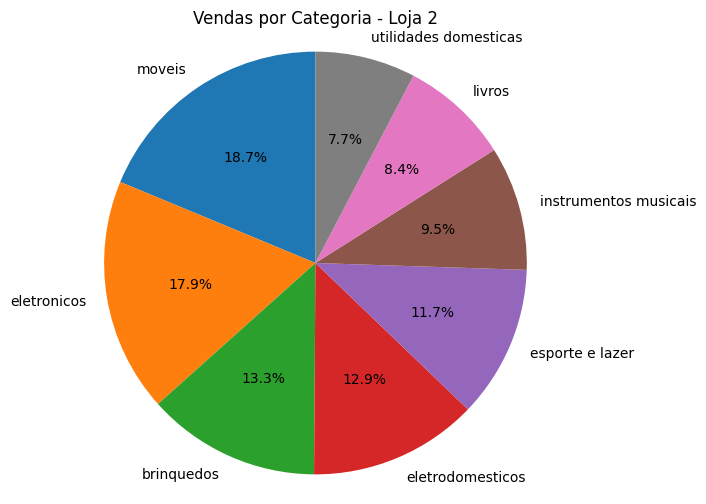

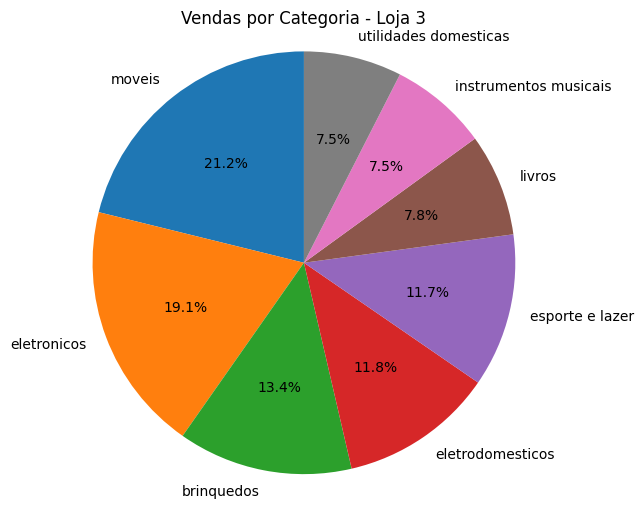

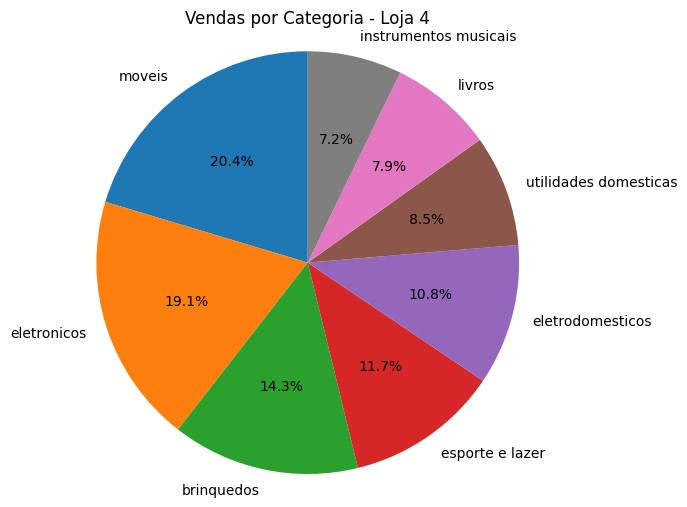

In [29]:
# Gráficos em pizza individuais para cada loja (em %)
for i, venda_categoria in enumerate(venda_por_categoria, start=1):
    plt.figure(figsize=(6, 6))
    plt.pie(venda_categoria, labels=venda_categoria.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'Vendas por Categoria - Loja {i}')
    plt.axis('equal')  # Deixa o círculo redondo
    plt.show()

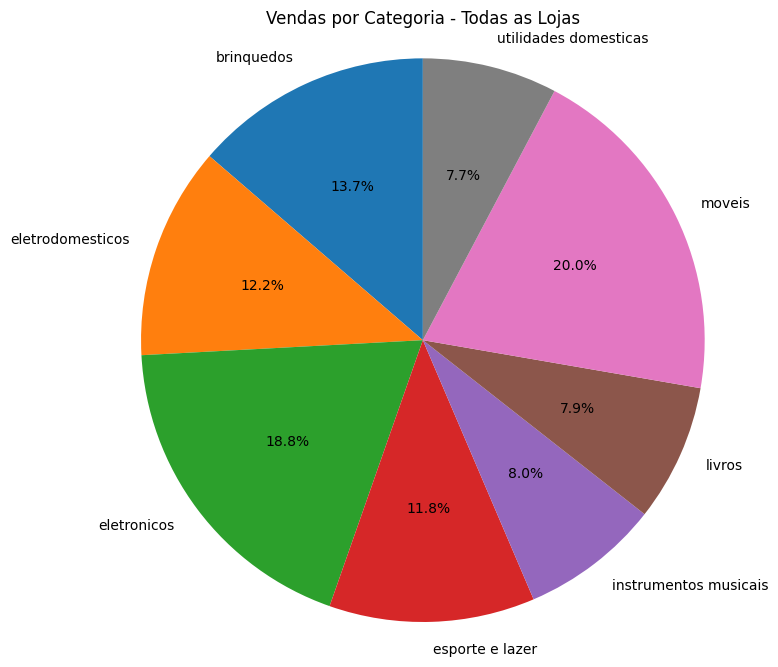

In [30]:
# gráfico pizza total em %

# Somar todas as vendas por categoria
vendas_totais = pd.Series(dtype=int)

for venda_categoria in venda_por_categoria:
    vendas_totais = vendas_totais.add(venda_categoria, fill_value=0)

# cria o gráfico único
plt.figure(figsize=(8, 8))
plt.pie(vendas_totais, labels=vendas_totais.index, autopct='%1.1f%%', startangle=90)
plt.title('Vendas por Categoria - Todas as Lojas')
plt.axis('equal')
plt.show()

# 3. Média de Avaliação das Lojas
Neste passo, vamos calcular a média das avaliações dos clientes para cada loja. O objetivo é **entender a satisfação dos clientes com os produtos vendidos**.

In [31]:
# média das avaliações com duas casas decimais

media_avaliacao_por_loja = []

for i, loja in enumerate(lojas, start=1):
    media_avaliacao = round(loja['Avaliação da compra'].mean(),2)
    media_avaliacao_por_loja.append(media_avaliacao)
    print(f"Média de avaliação da loja {i}:\n{media_avaliacao}\n")

Média de avaliação da loja 1:
3.98

Média de avaliação da loja 2:
4.04

Média de avaliação da loja 3:
4.05

Média de avaliação da loja 4:
4.0



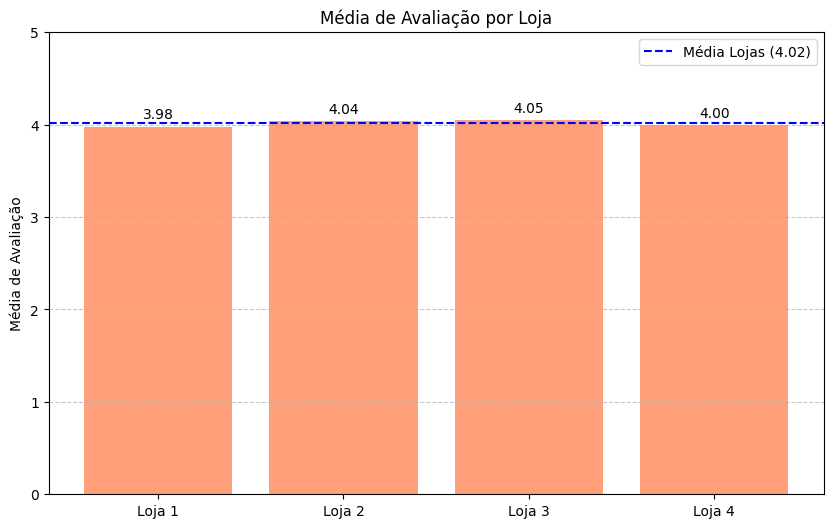

In [32]:
# gráfico de barras

# Nomes das lojas
nomes_lojas = [f"Loja {i}" for i in range(1, len(media_avaliacao_por_loja) + 1)]

# Calcular a média nacional (média de todas as lojas)
media_lojas = round(sum(media_avaliacao_por_loja) / len(media_avaliacao_por_loja), 2)

# Criar o gráfico
plt.figure(figsize=(10, 6))
barras = plt.bar(nomes_lojas, media_avaliacao_por_loja, color='lightsalmon')

plt.ylim(0, 5)
plt.ylabel('Média de Avaliação')
plt.title('Média de Avaliação por Loja')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Linha da média nacional
plt.axhline(y=media_lojas, color='blue', linestyle='--', label=f'Média Lojas ({media_lojas})')

# Adiciona os valores em cima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.05,
             f'{altura:.2f}', ha='center', va='bottom')

# Mostrar a legenda
plt.legend()

plt.show()

# 4. Produtos Mais e Menos Vendidos
Neste passo, deve identificar quais produtos foram os **mais vendidos** e os **menos vendidos** em cada loja.  Ao final, visualize os resultados de forma que fique claro quais produtos se destacaram nas vendas de **cada loja**.

In [33]:
venda_por_produtos = []

for i, loja in enumerate(lojas, start=1):
    venda_produto = loja['Produto'].value_counts()
    venda_por_produtos.append(venda_produto)
    print(f"Vendas por produto da loja {i}:\n{venda_produto}\n")

Vendas por produto da loja 1:
Produto
Micro-ondas                    60
TV Led UHD 4K                  60
Guarda roupas                  60
Secadora de roupas             58
Cômoda                         56
Blocos de montar               56
Bola de basquete               55
Bicicleta                      54
Copo térmico                   54
Geladeira                      54
Impressora                     54
Bateria                        53
Faqueiro                       52
Carrinho controle remoto       52
Modelagem preditiva            51
Fone de ouvido                 50
Xadrez de madeira              49
Celular Plus X42               49
Lava louças                    48
Lavadora de roupas             47
Guitarra                       47
Violão                         46
Sofá retrátil                  46
Cadeira de escritório          46
Fogão                          45
Cama box                       44
Kit banquetas                  44
Smart TV                       44
Cama king 

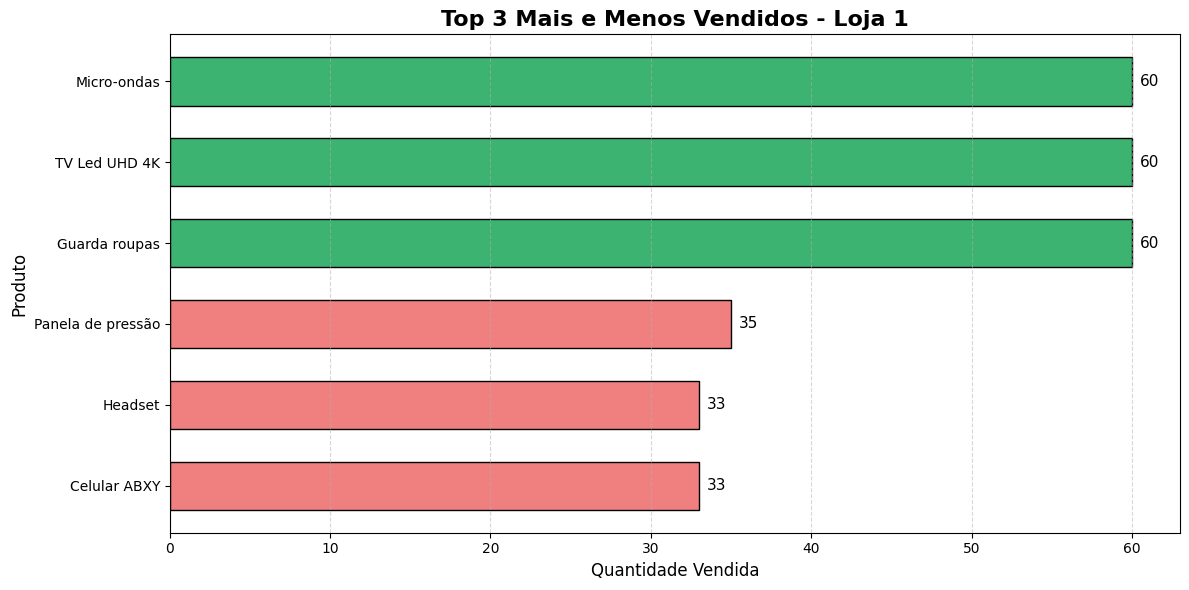

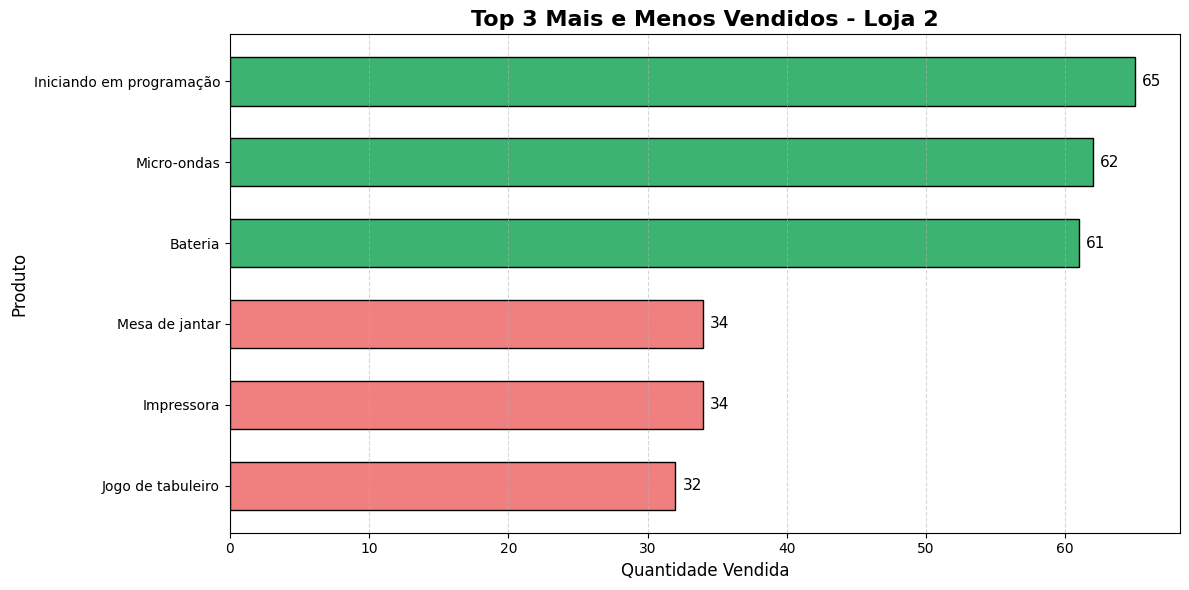

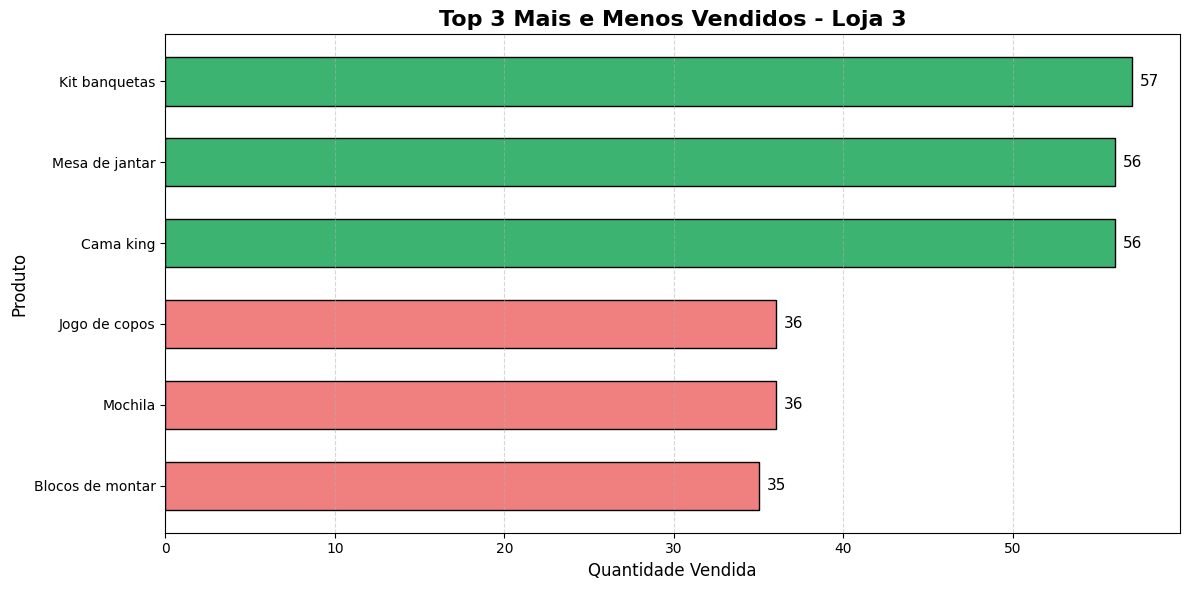

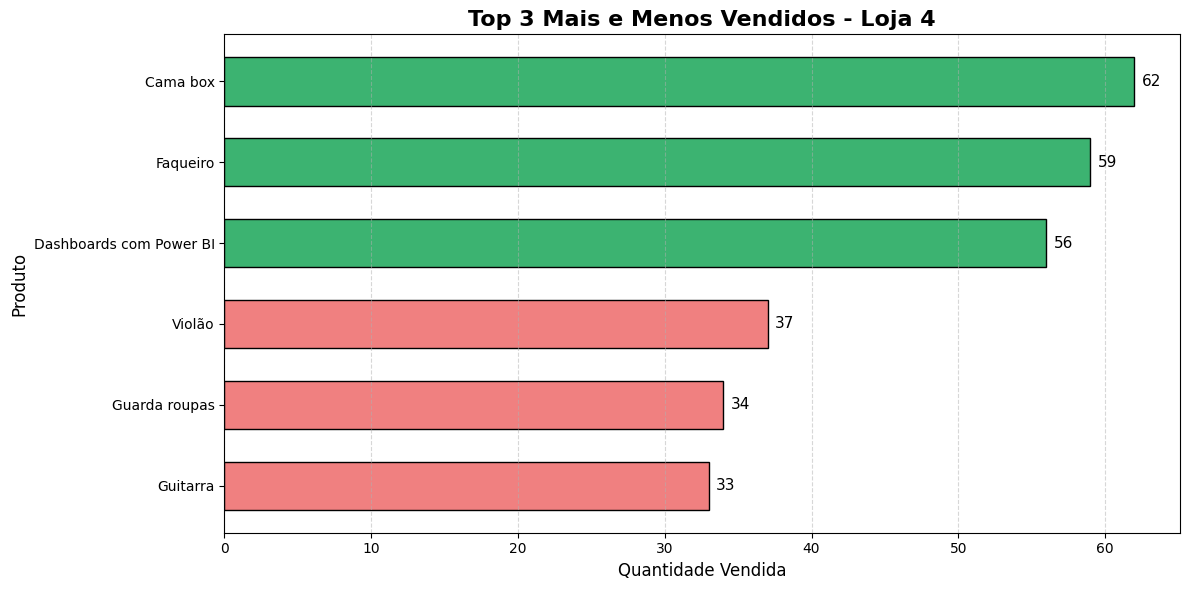

In [34]:
for i, loja in enumerate(lojas, start=1):
    vendas = loja['Produto'].value_counts()

    # Produtos mais vendidos
    top_3 = vendas.nlargest(3)

    # Remover do DataFrame para pegar os menos vendidos
    vendas_restantes = vendas.drop(top_3.index)
    bottom_3 = vendas_restantes.nsmallest(3)

    # Juntando top e bottom (sem repetição)
    produtos_combinados = list(top_3.index) + list(bottom_3.index)
    vendas_combinadas = list(top_3.values) + list(bottom_3.values)

    # Ordenar pela quantidade vendida (decrescente)
    produtos_vendas_ordenados = sorted(zip(produtos_combinados, vendas_combinadas),
                                        key=lambda x: x[1], reverse=True)
    produtos_ordenados, vendas_ordenadas = zip(*produtos_vendas_ordenados)

    # Cores
    cores = ['mediumseagreen' if produto in top_3.index else 'lightcoral' for produto in produtos_ordenados]

    # Criar gráfico
    plt.figure(figsize=(12, 6))
    bars = plt.barh(produtos_ordenados, vendas_ordenadas, color=cores, edgecolor='black', height=0.6)

    plt.gca().invert_yaxis()
    plt.title(f'Top 3 Mais e Menos Vendidos - Loja {i}', fontsize=16, weight='bold')
    plt.xlabel('Quantidade Vendida', fontsize=12)
    plt.ylabel('Produto', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Anotar valores
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{int(width)}', va='center', ha='left', fontsize=11)

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()


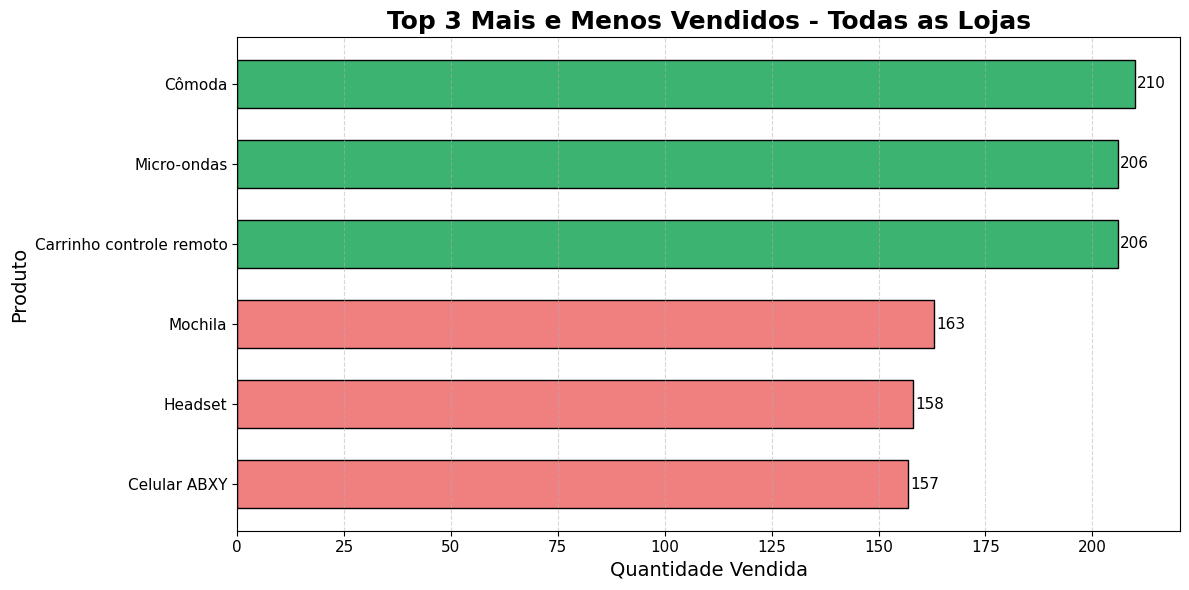

In [35]:
# Juntar todos os dados das lojas
todos_produtos = []

for loja in lojas:
    todos_produtos.extend(loja['Produto'])

# Contar todas as vendas

contador_vendas = Counter(todos_produtos)

# Converter para duas listas: produto e quantidade
produtos, quantidades = zip(*contador_vendas.items())

# Top 3 mais vendidos
top_3 = sorted(contador_vendas.items(), key=lambda x: x[1], reverse=True)[:3]

# Bottom 3 menos vendidos
bottom_3 = sorted(contador_vendas.items(), key=lambda x: x[1])[:3]

# Juntar top e bottom
produtos_combinados = [produto for produto, _ in top_3] + [produto for produto, _ in bottom_3]
vendas_combinadas = [venda for _, venda in top_3] + [venda for _, venda in bottom_3]

# Cores: verde para top 3, vermelho para bottom 3
cores = ['mediumseagreen'] * 3 + ['lightcoral'] * 3

# Ordenar pelo número de vendas (decrescente)
produtos_vendas = list(zip(produtos_combinados, vendas_combinadas))
produtos_vendas.sort(key=lambda x: x[1], reverse=True)

produtos_ordenados, vendas_ordenadas = zip(*produtos_vendas)

# Gráfico
plt.figure(figsize=(12, 6))
bars = plt.barh(produtos_ordenados, vendas_ordenadas, color=cores, edgecolor='black', height=0.6)

plt.gca().invert_yaxis()
plt.title('Top 3 Mais e Menos Vendidos - Todas as Lojas', fontsize=18, weight='bold')
plt.xlabel('Quantidade Vendida', fontsize=14)
plt.ylabel('Produto', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Anotar valores
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', ha='left', fontsize=11)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# 5. Frete Médio por Loja
Neste passo, vamos calcular o **custo médio de frete** para cada loja. O objetivo é entender quanto, **em média**, está sendo gasto com frete para **cada uma das lojas**.

In [36]:
media_frete_por_loja = []
print("Frete médio por loja")
for i, loja in enumerate(lojas, start=1):
    frete_medio = round(loja['Frete'].mean(),2)
    media_frete_por_loja.append(frete_medio)
    print(f'Loja {i}: R${frete_medio}')

Frete médio por loja
Loja 1: R$34.69
Loja 2: R$33.62
Loja 3: R$33.07
Loja 4: R$31.28


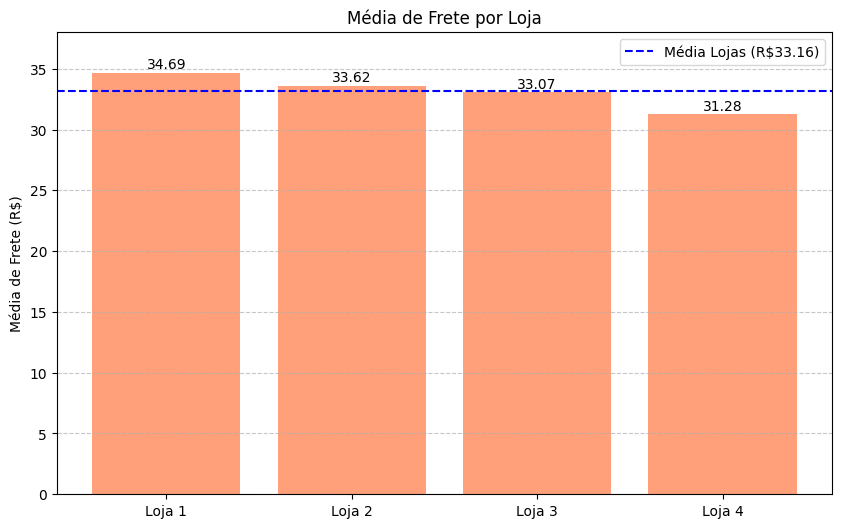

In [37]:
# gráfico de barras

# Nomes das lojas
nomes_lojas = [f"Loja {i}" for i in range(1, len(media_avaliacao_por_loja) + 1)]

# Calcular a média nacional (média de todas as lojas)
media_lojas = round(sum(media_frete_por_loja) / len(media_frete_por_loja), 2)

# Criar o gráfico
plt.figure(figsize=(10, 6))
barras = plt.bar(nomes_lojas, media_frete_por_loja, color='lightsalmon')

plt.ylim(0,38)
plt.ylabel('Média de Frete (R$)')
plt.title('Média de Frete por Loja')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Linha da média nacional
plt.axhline(y=media_lojas, color='blue', linestyle='--', label=f'Média Lojas (R${media_lojas})')

# Adiciona os valores em cima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.05,
             f'{altura:.2f}', ha='center', va='bottom')

# Mostrar a legenda
plt.legend()

plt.show()

# 6. Análise de Desempenho Geográfico

In [38]:
latitudes = [loja["lat"].tolist() for loja in lojas]
longitudes = [loja["lon"].tolist() for loja in lojas]

latitudes = latitudes[0]
longitudes = longitudes[0]

In [39]:
coordenadas = list(zip(latitudes, longitudes))
print(f"Total de coordenadas: {len(coordenadas)}")
print(f"Coordenadas únicas: {len(set(coordenadas))}")

Total de coordenadas: 2359
Coordenadas únicas: 26


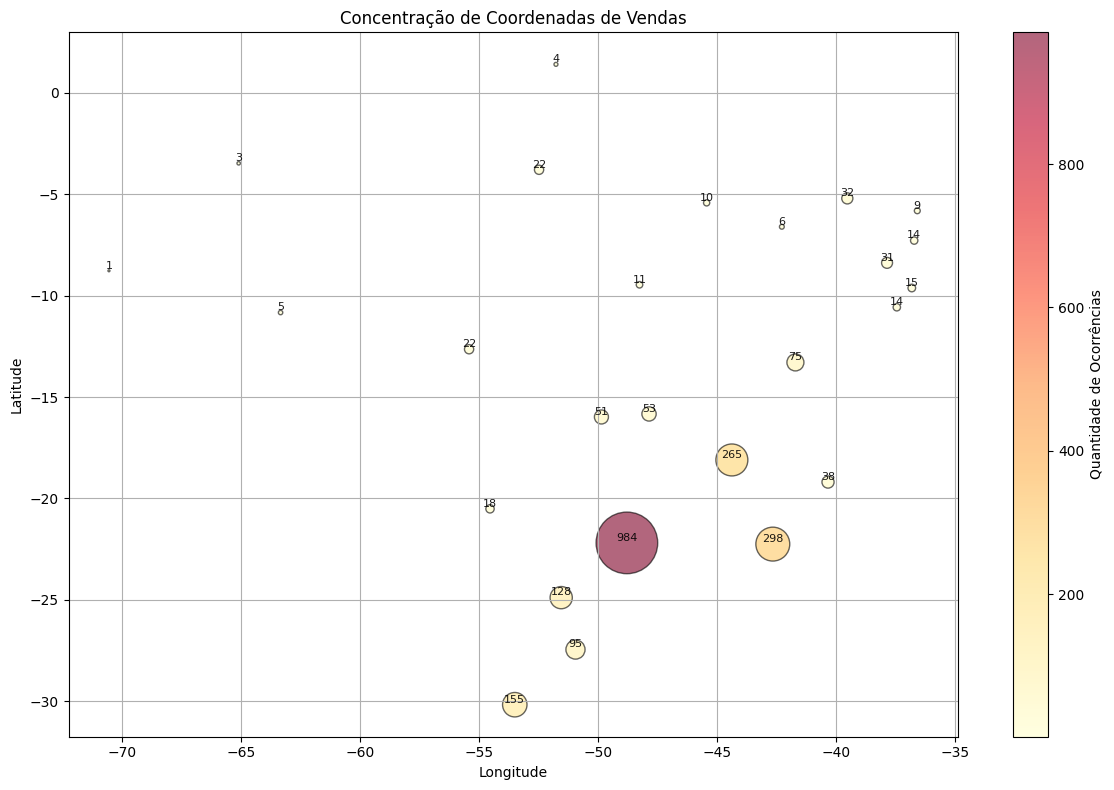

In [49]:
# Agrupar coordenadas repetidas
coordenadas = list(zip(latitudes, longitudes))
contagem = Counter(coordenadas)

# Separar coordenadas únicas e suas frequências
latitudes_unicas = [coord[0] for coord in contagem.keys()]
longitudes_unicas = [coord[1] for coord in contagem.keys()]
frequencias = [contagem[coord] for coord in contagem.keys()]

# Criar o gráfico
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    longitudes_unicas,
    latitudes_unicas,
    s=[f * 2 for f in frequencias],  # Ajuste o multiplicador conforme o visual
    alpha=0.6,
    edgecolors='k',
    c=frequencias,
    cmap='YlOrRd'
)

# Adicionar os valores de frequência em cada ponto
for lon, lat, freq in zip(longitudes_unicas, latitudes_unicas, frequencias):
    plt.text(
        lon,
        lat + 0.01,  # Deslocamento vertical para não sobrepor
        str(freq),
        fontsize=8,
        ha='center',
        va='bottom',
        color='black',
        alpha=0.9
    )

plt.colorbar(scatter, label='Quantidade de Ocorrências')
plt.title('Concentração de Coordenadas de Vendas')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
# Juntar as coordenadas válidas como pares (lat, lon)
coordenadas = [(lat, lon) for lat, lon in zip(latitudes, longitudes)]

# Centralizar o mapa nas coordenadas médias
lat_media = sum(latitudes) / len(latitudes)
lon_media = sum(longitudes) / len(longitudes)

# Criar o mapa base
mapa = folium.Map(location=[lat_media, lon_media], zoom_start=5)

# Adicionar o HeatMap
HeatMap(coordenadas, radius=10, blur=15, max_zoom=1).add_to(mapa)

# Exibir o mapa mapa

mapa

# 7. Conclusões
A partir das análises realizadas, os seguintes insights foram destacados:

- **Loja 1** foi responsável pelo **maior faturamento bruto**, seguida pela Loja 2, enquanto a Loja 4 apresentou o menor desempenho.
- A distribuição geográfica revelou uma forte concentração de vendas na **região sudeste**, sobretudo em SP.
- O valor do frete médio apresentou **pouca variação entre as lojas**, o que faz sentido tendo em vista que a maior parte das vendas se concentrou nas mesmas regiões. Ainda assim, o maior frete médio é o da loja 1 e o menor o da loja 4.
- A avaliação média das lojas foi **regular** (**4.02** de um máximo de 5). A loja com **menor desempenho nas avaliações foi a loja 1** e a com **melhor foi a loja 3**.
- As duas categorias de produtos com maior vendagem na rede foram **móveis e eletrônicos**, totalizando juntas **38,8%** das vendas. Além disso, estas duas categorias foram responsáveis também pela por cerca de 38% das vendas de cada loja individualmente.
- Já as duas categorias com **menor vendagem** na rede foram **utilidades domésticas e livros**. Juntas, totalizam **apenas 15,6%**. Novamente, algo muito similar acontece também individualmente em cada loja.
- Essas descobertas podem orientar ações estratégicas como expansão de cobertura, promoções regionais e ajustes logísticos, além de um esforço para melhor a experiência do cliente.
- De forma geral, as quatro lojas apresentam desempenho geral muito parecidos. Entretanto, tendo em vista seu menor faturamento bruto e segunda pior avaliação média dos clientes, acreditamos que - caso seja esta a decisão da diretoria - a **loja que deveria ser encerrada é a loja 4**. Vale apontar que apesar desta loja possuir o menor valor médio de frete, isto tem pouco impacto no faturamento líquido da loja.
